In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats
from pathlib import Path

In [ ]:
TITANIC_DATA_PATH   = Path('../practice/datasets/kaggle/titanic/train.csv')
TITANIC_MODEL_DIR   = Path('../practice/models/titanic'); TITANIC_MODEL_DIR.mkdir(exist_ok=True)
TITANIC_OUTPUT_DIR  = Path('../practice/outputs/titanic'); TITANIC_OUTPUT_DIR.mkdir(exist_ok=True)

In [4]:
HEART_DISEASE_DATA_PATH   = Path('../practice/datasets/kaggle/heart-disease/train.csv')
HEART_DISEASE_MODEL_DIR   = Path('../practice/models/heart-disease'); HEART_DISEASE_MODEL_DIR.mkdir(exist_ok=True)
HEART_DISEASE_OUTPUT_DIR  = Path('../practice/outputs/heart-disease'); HEART_DISEASE_OUTPUT_DIR.mkdir(exist_ok=True)

In [5]:
NYSE_DATA_PATH   = Path('../practice/datasets/kaggle/nyse/')
NYSE_MODEL_DIR   = Path('../practice/models/nyse'); NYSE_MODEL_DIR.mkdir(exist_ok=True)
NYSE_OUTPUT_DIR  = Path('../practice/outputs/nyse'); NYSE_OUTPUT_DIR.mkdir(exist_ok=True)

In [6]:
NEWS_CATEGORY_DATA_PATH   = Path('../practice/datasets/kaggle/news-category/')
NEWS_CATEGORY_MODEL_DIR   = Path('../practice/models/news-category'); NEWS_CATEGORY_MODEL_DIR.mkdir(exist_ok=True)
NEWS_CATEGORY_OUTPUT_DIR  = Path('../practice/outputs/news-category'); NEWS_CATEGORY_OUTPUT_DIR.mkdir(exist_ok=True)

In [7]:
titanic_df=pd.read_csv(TITANIC_DATA_PATH)

In [8]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [108]:
missing=pd.DataFrame({"count":titanic_df.isna().sum(),
                      "pct": titanic_df.isna().mean().mul(100).round(2)}).query('count >0').sort_values('pct',ascending=False)
missing

,count,pct
Cabin,687,77.10
Embarked,2,0.22


In [17]:
missing = pd.DataFrame({
    "count": titanic_df.isna().sum(),
    "pct":   titanic_df.isna().mean().mul(100).round(2)
}).query('count >0').sort_values('pct',ascending=False)
missing

,count,pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [21]:
# Missingness correlation — helps identify MAR
miss_matrix = titanic_df.isna().astype(int)
miss_matrix

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,0,0,0,0,0,0,0,0,0,1,0
887,0,0,0,0,0,0,0,0,0,0,0,0
888,0,0,0,0,0,1,0,0,0,0,1,0
889,0,0,0,0,0,0,0,0,0,0,0,0


In [40]:
miss_matrix.corr(method='spearman')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Survived,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pclass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.144111,-0.023616
SibSp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Parch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
!pip install missingno

In [28]:
import missingno as msno

<Axes: >

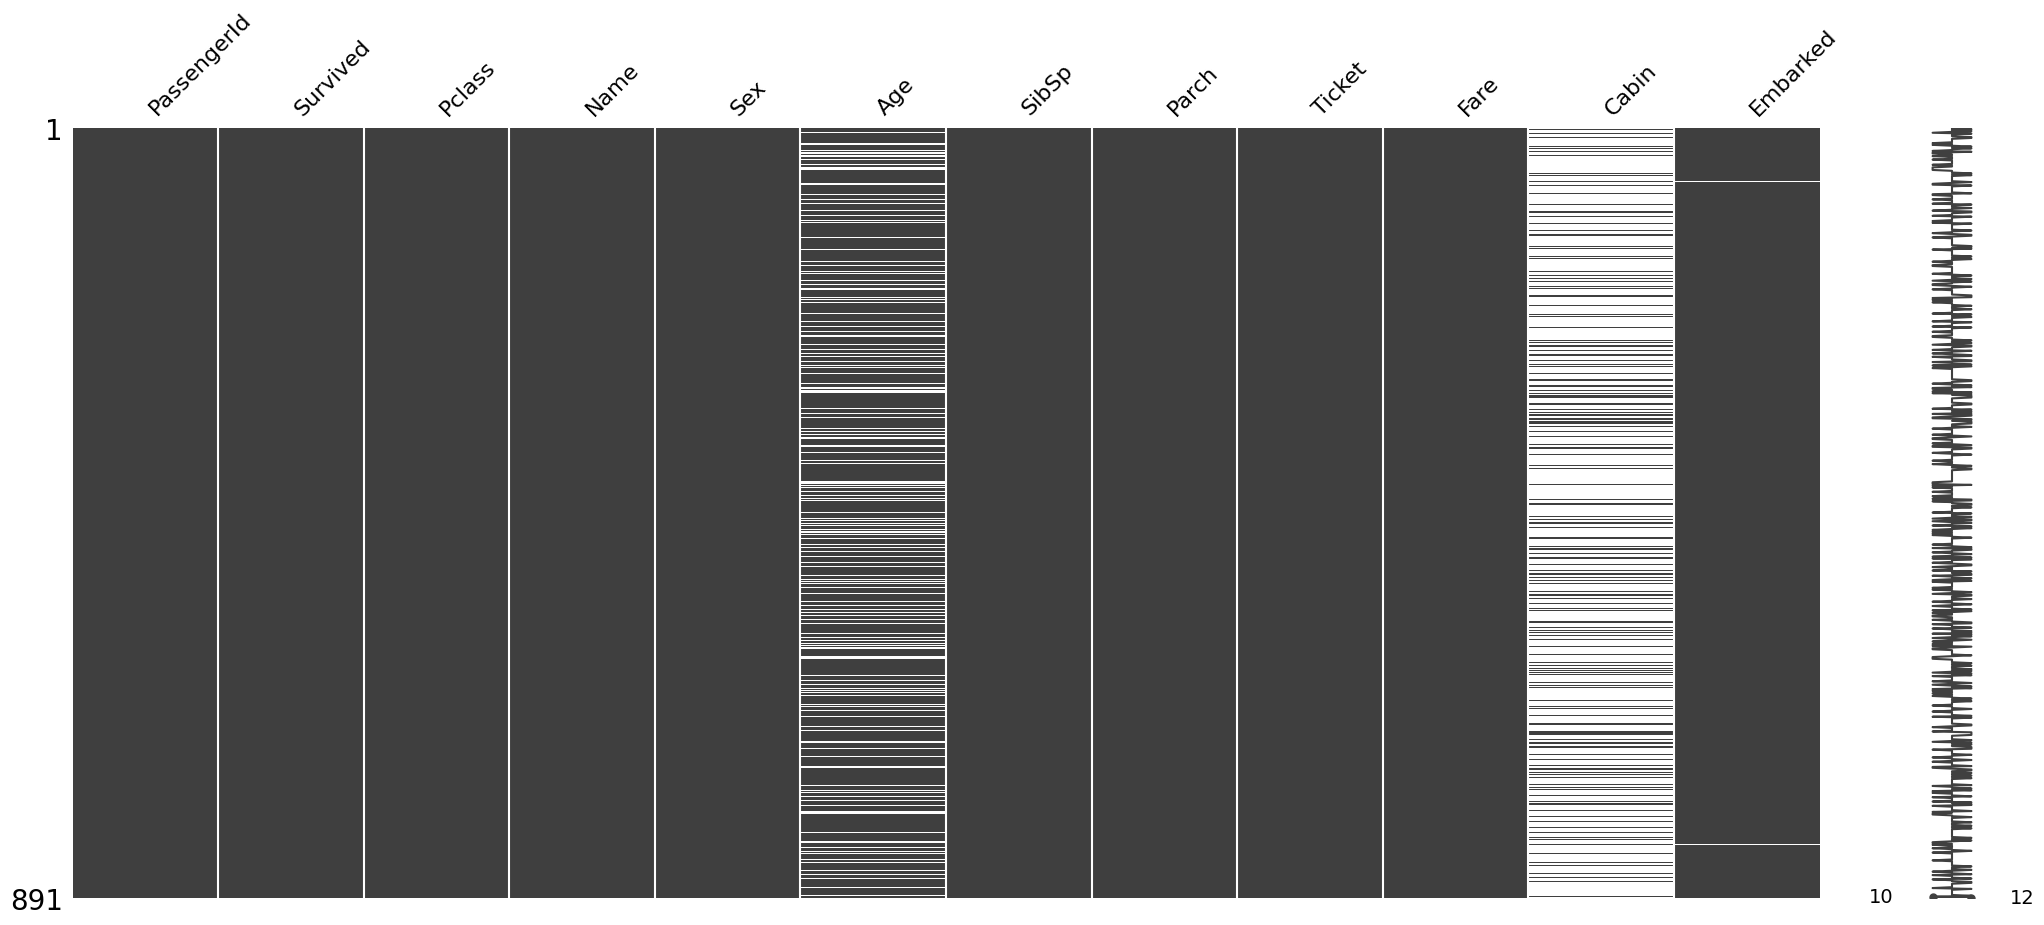

In [42]:
msno.matrix(titanic_df)
#msno.heatmap(titanic_df)

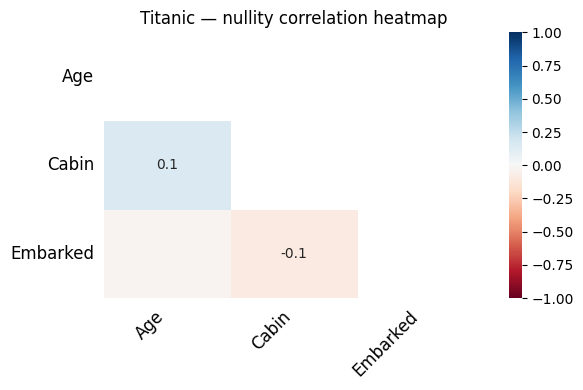

In [43]:
msno.heatmap(titanic_df, figsize=(6, 4), fontsize=12)
plt.title("Titanic — nullity correlation heatmap")
plt.tight_layout()
plt.show()

observations:

Age X Cabin Positive correlation +0.144111 ~= +0.14  MAR signal — weak

When Age is missing, Cabin is also slightly more likely to be missing. Both tend to be absent in 3rd-class passengers who had poorer documentation. The shared driver is Pclass — an observable column. This is a weak MAR signal telling you to group Age imputation by Pclass.

Cabin X Embarked  Negative correlation -0.087042  ~=0.1 - Near zero — largely independent

When Cabin is missing, Embarked is very slightly more likely to be present. At -0.1 this is practically zero — only 2 Embarked values are missing. The negative sign is noise caused by those 2 rows. Treat as independent. Embarked is safely MCAR.

Age X Embarked -0.023616 Near zero

Age missing rows and Embarked missing rows have zero relationship. The 2 passengers with no Embarked port are not the same passengers with no Age. They go missing for completely unrelated reasons. This confirms Embarked is safe to mode-fill without any grouping.

before getting into techniques we will explore different dataset



with different titanic data set for an instance we got heat map like below lets go through
![Screenshot 2026-05-05 at 1.39.12 PM.png](<attachment:Screenshot 2026-05-05 at 1.39.12 PM.png>)
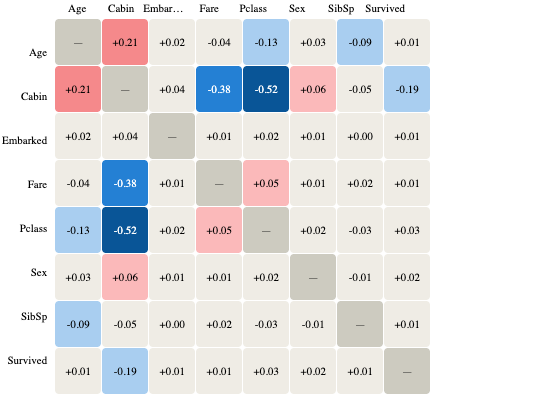

Age × Cabin +0.21 moderate positive (+0.21)

When Age is missing, Cabin tends to also be missing — both are more likely absent for lower-class passengers (3rd class) who are less documented. MAR signal: both driven by Pclass.

Age × Embarked +0.02  Near zero — 

no meaningful relationship between the missingness patterns of Age and Embarked. They go missing independently.


Age × Pclass -0.13 weak negative (-0.13)

When Age is missing, Pclass slightly tends toward 3. 3rd class passengers had less documentation. Weak MAR signal — use Pclass as a grouping variable when imputing Age.

Age × SibSp -0.09 Weak negative — 

when Age is missing, SibSp tends to be present (and vice versa). Unusual — investigate whether one column's presence triggers the other's absence.

Cabin × Fare -0.38 moderate negative (-0.38)

When Cabin is missing, Fare tends to have a lower value (present but small). Passengers who paid more had their cabin recorded. Cabin missingness is partially MAR on Fare.

Pclass × Cabin -0.52 strong negative (-0.52)

This is the most important cell. When Cabin is missing, Pclass tends to have a LOWER value (i.e., 1st class). 

Wait — actually: Cabin missingness is high for Pclass 2 and 3. 

The negative correlation here means: when Cabin is observed (not missing), 

Pclass is missing less too — rich passengers (Pclass=1) have both Cabin recorded. Strong MAR signal.

What the heatmap actually measures

msno.heatmap() computes the Spearman correlation between the missingness indicators of each column pair — not between the column values themselves

The three readings — what each value zone means  

Zone 1 — Near zero (roughly -0.1 to +0.1)
 
 The two columns go missing completely independently of each other. No relationship. This is consistent with MCAR in both columns, or simply that different processes cause their gaps.
In Titanic: Embarked × SibSp ≈ 0.00. The two missing Embarked rows have nothing to do with the SibSp column. Treat them separately.

Zone 2 — Positive correlation (+0.2 to +1.0)

Rows missing in column A are also likely missing in column B. They share a common cause of missingness. This is the strongest MAR signal — look for a third column that explains both.
In Titanic: Age × Cabin ≈ +0.21. Both tend to be missing for the same passengers — those in 3rd class with poor documentation. The shared cause is Pclass. This tells you to group by Pclass when imputing Age.

Zone 3 — Negative correlation (-0.2 to -1.0)

When A is missing, B tends to be present and vice versa. One column's absence is associated with the other's presence. This is unusual and worth investigating — it can signal that the two columns are alternative representations of the same thing, or that a process records one OR the other but not both.
In Titanic: Cabin × Pclass ≈ -0.52. When Cabin is missing (3rd class), Pclass is recorded (always complete). When Cabin is present (1st class), Pclass is also recorded. This negative value reflects the asymmetry in who had cabins — not a true negative pattern, but a structural one driven by wealth.

Here is the Programmatic interpretation

In [51]:
miss = titanic_df.isna().astype(int)
corr = miss.corr(method="spearman")
missing_cols = [c for c in titanic_df.columns if titanic_df[c].isna().any()]
for i, ca in enumerate(missing_cols):
        for cb in missing_cols[i+1:]:
            print(cb)
            print(i,ca,cb)
            print(corr.loc[ca,cb])


Cabin
0 Age Cabin
0.14411087922884733
Embarked
0 Age Embarked
-0.023615744670011096
Embarked
1 Cabin Embarked
-0.08704170753148568


In [90]:
def interpret_heatmap(df : pd.DataFrame,threshold: float=0.1):
    miss = df.isna().astype(int)
    corr = miss.corr(method="spearman")
    results ={"strong_positive":[],"strong_negative":[],
              "near_zero":[],"outcome_correlated":[]}
    missing_cols=[c for c in df.columns if df[c].isna().any()] # capturing cols having missing values
    for i, ca in enumerate(missing_cols):
        for cb in missing_cols[i+1:]:
            v = corr.loc[ca, cb]
            if v > threshold:
                results["strong_positive"].append((ca, cb, round(v, 3)))
            elif v < -threshold:
                results["strong_negative"].append((ca, cb, round(v, 3)))
            else:
                results["near_zero"].append((ca, cb, round(v, 3)))

    return results
    

In [88]:
r = interpret_heatmap(titanic_df)

print("=== Shared-cause missingness (group these when imputing) ===")
for a, b, v in sorted(r["strong_positive"], key=lambda x: -x[2]):
    print(f"  {a} × {b}: +{v}")

print("\n=== Structural opposition (investigate, may be alternative fields) ===")
for a, b, v in sorted(r["strong_negative"], key=lambda x: x[2]):
    print(f"  {a} × {b}: {v}")

print("\n=== Correlated with outcome — MNAR risk ===")
for col, v in r["outcome_correlated"]:
    print(f"  {col}: {v}  ← add missingness indicator flag")

['Age', 'Cabin', 'Embarked']
=== Shared-cause missingness (group these when imputing) ===
  Age × Cabin: +0.144

=== Structural opposition (investigate, may be alternative fields) ===

=== Correlated with outcome — MNAR risk ===


In [ ]:
#interpret_heatmap(df=titanic_df,threshold=0.1)

{'strong_positive': [('Age', 'Cabin', np.float64(0.144))],
 'strong_negative': [],
 'near_zero': [('Age', 'Embarked', np.float64(-0.024)),
  ('Cabin', 'Embarked', np.float64(-0.087))],
 'outcome_correlated': []}

Common misreadings to avoid

referring dummy example  from above heat map

The heatmap does NOT tell you the correlation between column values. 

Age × Fare = -0.04 does not mean younger passengers paid less. It means the rows where Age is missing have almost no relationship to the rows where Fare is missing.

A cell value of +1.0 does not mean both columns are always missing together. It means whenever one is missing, so is the other — but both could be missing in only 2% of rows. Always check the missing rate separately with msno.bar().

A zero cell does not mean the columns are independent in value — only that their missingness patterns are independent.


<Axes: >

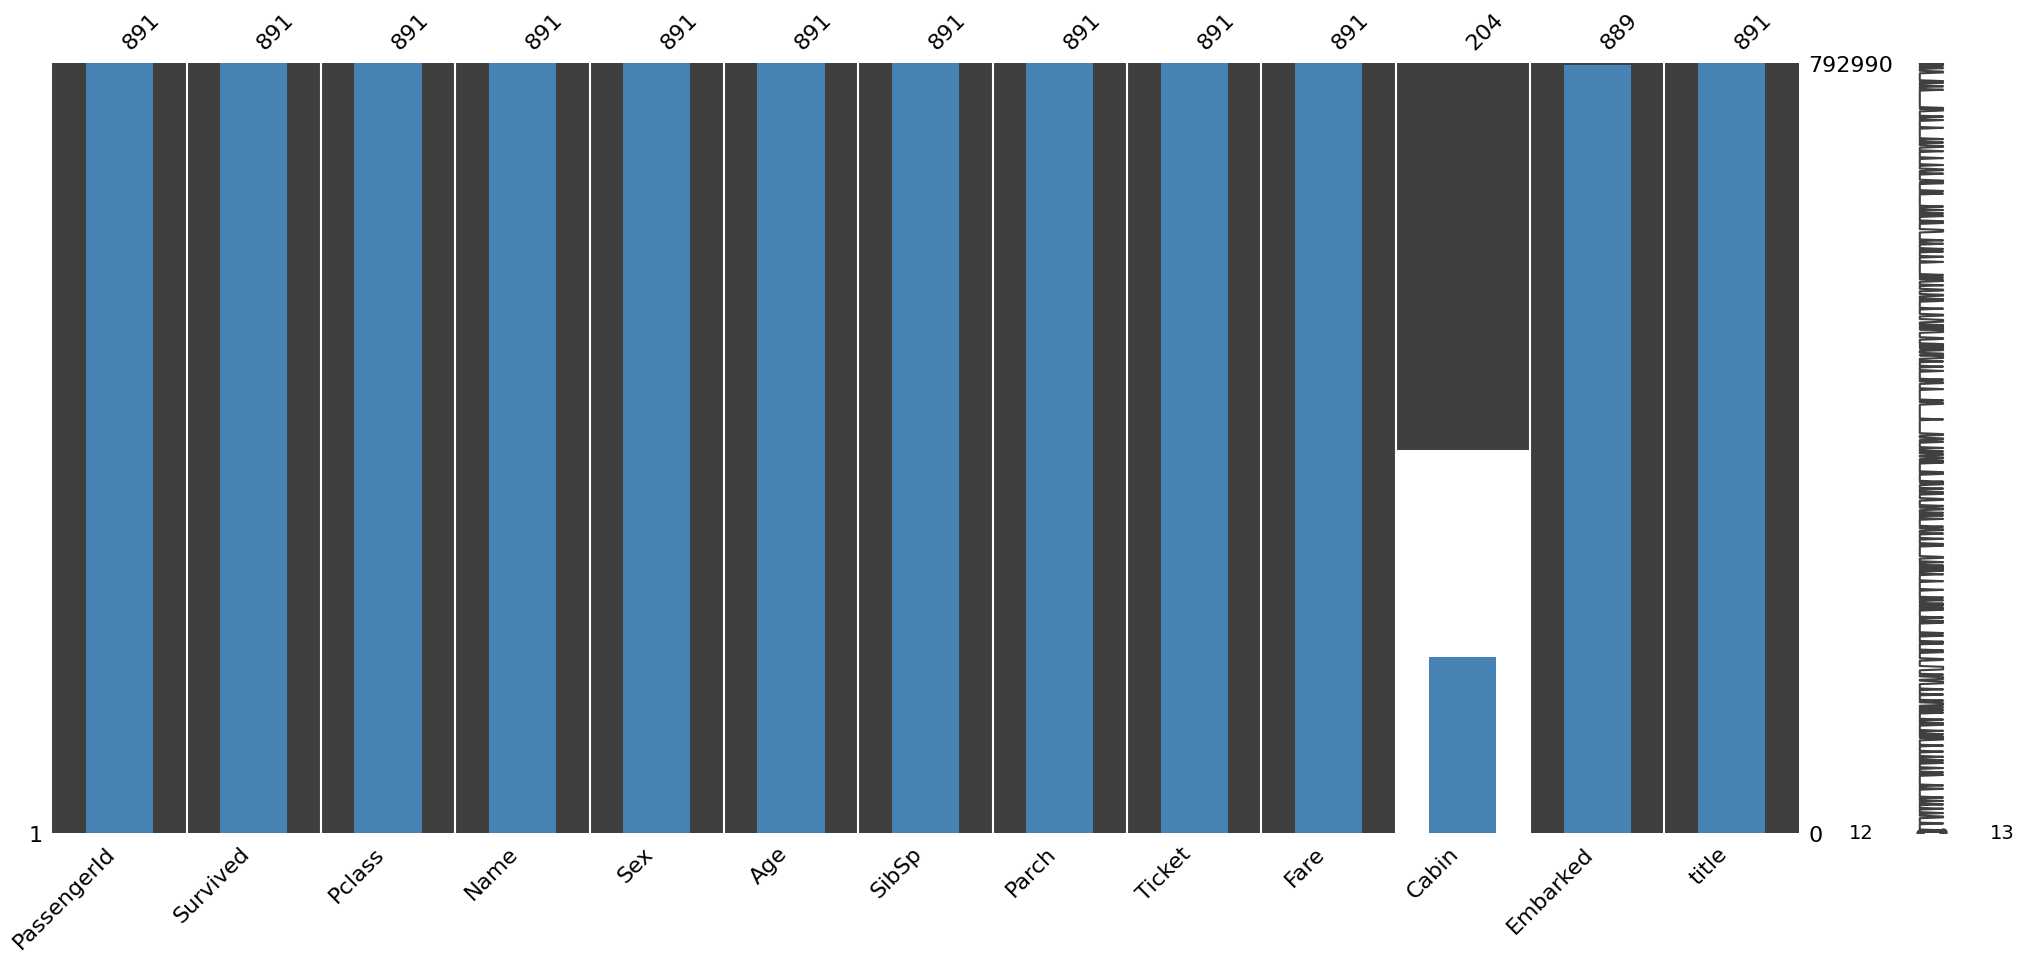

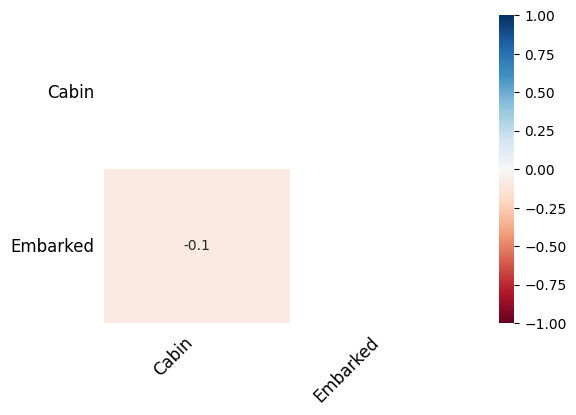

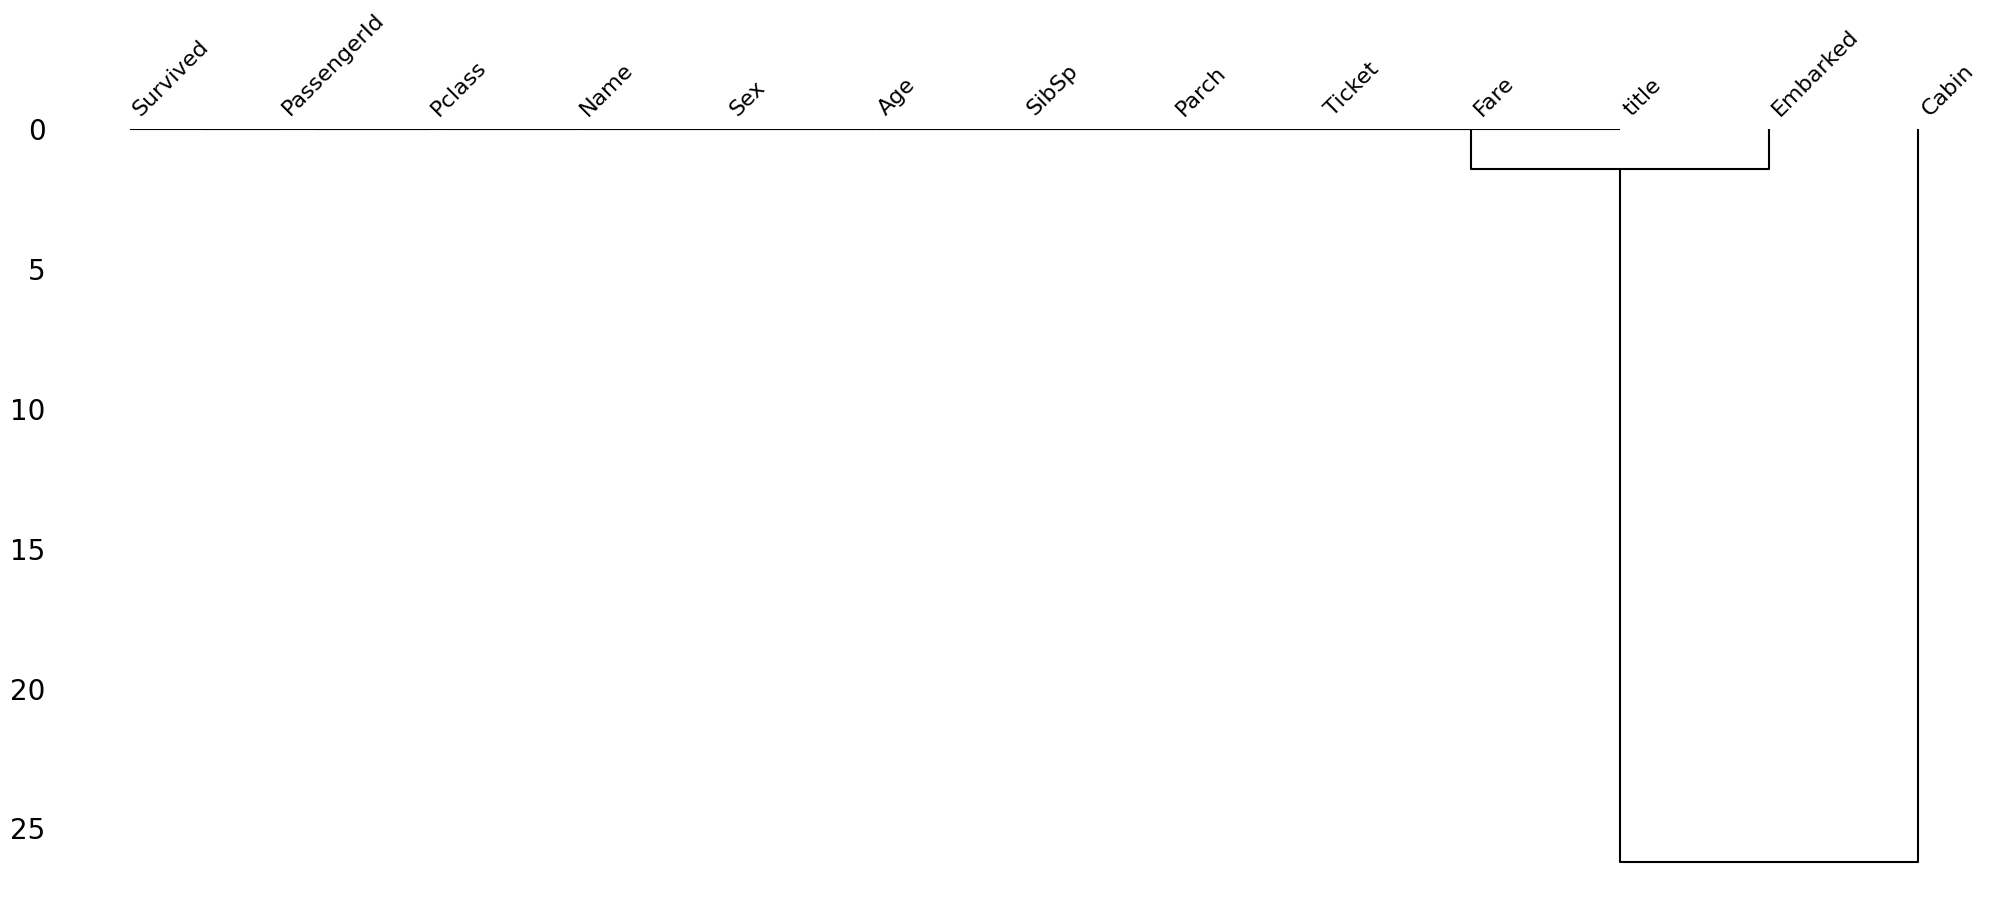

In [102]:
import missingno as msno

# 1. First look — where are the gaps and how big?
msno.matrix(titanic_df)
# Shows a white/black grid: white = missing, black = present
# Sparkline on right shows row-level completeness
# Use this FIRST before the heatmap

# 2. How much is missing per column? (bar chart)
msno.bar(titanic_df, color="steelblue")
# Y-axis = count of non-null values
# Use to prioritise: columns >50% missing need special treatment

# 3. Are any columns always missing together? (heatmap)
msno.heatmap(titanic_df,figsize=(6, 4), fontsize=12)
# Use AFTER matrix — to understand WHY patterns exist

# 4. Which columns cluster by missingness pattern? (dendrogram)
msno.dendrogram(titanic_df)
# Groups columns whose missingness co-occurs
# Age and Cabin might cluster together — confirming the +0.21 correlation
# Use to find grouping variables for imputation

The correct order is always: bar → matrix → heatmap → dendrogram. Each one builds on what the previous one showed you.

Action: when you impute Age, group by Pclass and passenger title. Don't use a global median.

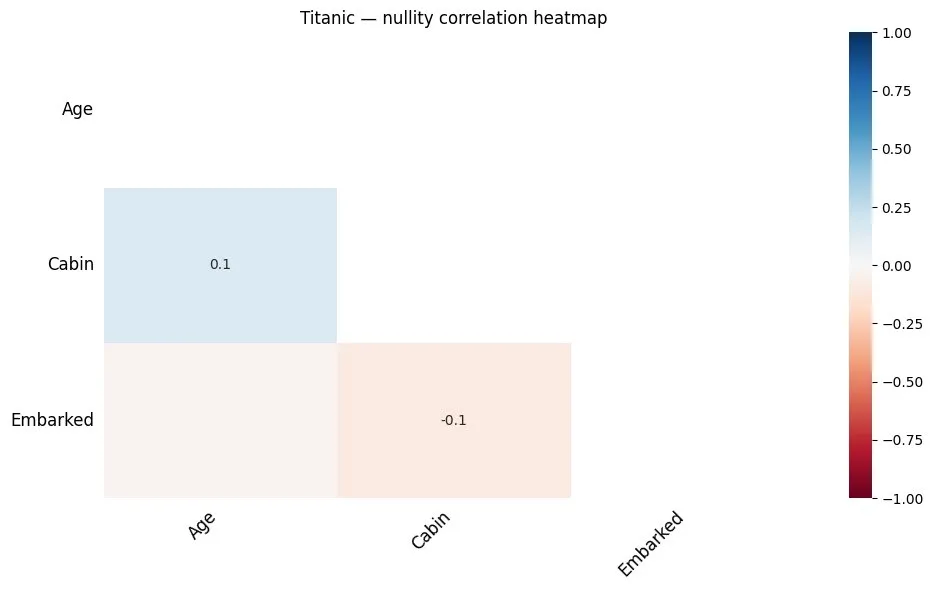.    now i am referring our original dataset heat map

In [100]:
# What the +0.1 tells you to do
title_map = {"Mr":0, "Mrs":1, "Miss":2, "Master":3, "Rare":4}
titanic_df["title"] = titanic_df["Name"].str.extract(r",\s*([^\.]+)\.")[0]
titanic_df["title"] = titanic_df["title"].map(title_map).fillna(4)

# Group median by (Pclass, title) — guided by the heatmap's MAR signal
group_medians = titanic_df.groupby(["Pclass","title"])["Age"].median()
titanic_df["Age"] = titanic_df.apply(
    lambda r: group_medians.get((r["Pclass"], r["title"]), titanic_df["Age"].median())
    if pd.isna(r["Age"]) else r["Age"], axis=1)

In [101]:
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,4.0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,2.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,18.0,1,2,W./C. 6607,23.4500,NaN,S,2.0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0.0
